In [271]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [272]:
import rasterio
import numpy as np
from pathlib import Path
from acc import  get_user_accuracy, get_producer_accuracy
from dist_s1.dist_plot import get_dist_s1_mpl_cmap
import matplotlib.pyplot as plt
from dem_stitcher.rio_window import read_raster_from_window
from colormap_utils import add_random_colors_colorbar, create_random_colormap_matplotlib
from basemaps import get_basemap_for_rasterio
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
from colormap_utils import add_continuous_colorbar_to_axes


In [273]:
dist_cmap, dist_norm = get_dist_s1_mpl_cmap()

In [366]:
KEY = '50NPL_geometry'
KEY = '50NPL_high_low_labels'
KEY = '12STA_greenup'
KEY = '22MGB_clearing'
KEY = '22MGB_clearing_2'
KEY = '50SMF_buildings_1'
KEY = '52TDP_buildings_s1_better'
KEY = '52TDP_buildings_s1_better_2'
KEY = '20LNJ_bolivia_fire'
KEY = '52TDP_new_water'
KEY = '50NPL_geometry'
KEY = '14RNU_water_recession'
KEY = '22MGB_logging_short'
KEY = '19TBG_forest_clearing_us'
KEY = '53LKC_inundated_vegetation_aus'
KEY = '49RGN_aquaculture_china'
KEY = '49RGN_aquaculture_china'
KEY = '36PVR_forest_loss_natural_sudan'
KEY = '19TBG_building_us'
KEY = '53KKU_water_new'
KEY = '19TBG_building_us'
KEY = '19TBG_forest_clearing_us'



In [ ]:

mgrs_tile_id = KEY.split('_')[0]
mgrs_tile_id

'19TBG'

In [368]:
PNG_DIR = Path('pngs')
CASE_PNG_DIR = PNG_DIR / KEY
CASE_PNG_DIR.mkdir(exist_ok=True, parents=True)

In [369]:
agg_dirs_parent = Path('aggregated_validation_dist_2024')
agg_dirs_parent.exists()

True

In [370]:
agg_dir = list(agg_dirs_parent.glob(f'*{mgrs_tile_id}/'))[0]
agg_dir, agg_dir.exists()

(PosixPath('aggregated_validation_dist_2024/other__19TBG'), True)

In [372]:
def get_paths(agg_dir: Path):
    veg_status_path = list(agg_dir.glob('dist_hls_veg_*.tif'))[0]
    gen_status_path = list(agg_dir.glob('dist_hls_gen_*.tif'))[0]
    dist_s1_path = list(agg_dir.glob('dist_s1_agg*.tif'))[0]
    dist_s1_count = list(agg_dir.glob('*_count_2024_s1.tif'))[0]
    dist_hls_count = list(agg_dir.glob('*_count_2024_hls.tif'))[0]
    lc_path = list(agg_dir.glob('*glad_lc_mask.tif'))[0]
    return {'veg_status': veg_status_path,
            'gen_status': gen_status_path,
            'dist_s1': dist_s1_path,
            'dist_s1_count': dist_s1_count,
            'dist_hls_count': dist_hls_count,
            'lc': lc_path}


In [373]:
path_dict = get_paths(agg_dir)

In [ ]:
from bounds_config import BOUNDS

bounds = BOUNDS[KEY]

In [374]:
path_dict = get_paths(agg_dir)
veg_status, p_veg = read_raster_from_window(path_dict['veg_status'], bounds)
veg_status = veg_status[0, ...]
gen_status, p_gen = read_raster_from_window(path_dict['gen_status'], bounds)
gen_status = gen_status[0, ...]
dist_s1, p_s1 = read_raster_from_window(path_dict['dist_s1'], bounds)
dist_s1 = dist_s1[0, ...]
dist_s1_count, p_s1_count = read_raster_from_window(path_dict['dist_s1_count'], bounds)
dist_s1_count = dist_s1_count[0, ...]
dist_hls_count, p_hls_count = read_raster_from_window(path_dict['dist_hls_count'], bounds)
dist_hls_count = dist_hls_count[0, ...]
lc, p_lc = read_raster_from_window(path_dict['lc'], bounds)
lc = lc[0, ...]

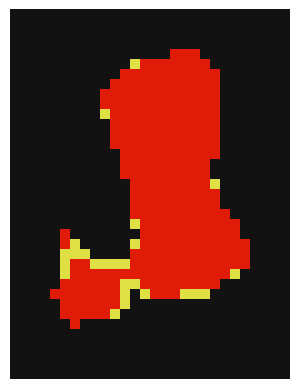

In [375]:
fig, ax = plt.subplots()
ax.imshow(dist_s1, cmap=dist_cmap, norm=dist_norm)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'dist_s1_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

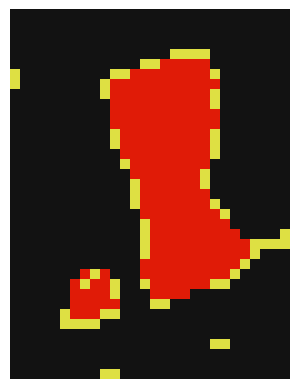

In [376]:
fig, ax = plt.subplots()
ax.imshow(veg_status, cmap=dist_cmap, norm=dist_norm)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'veg_status_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

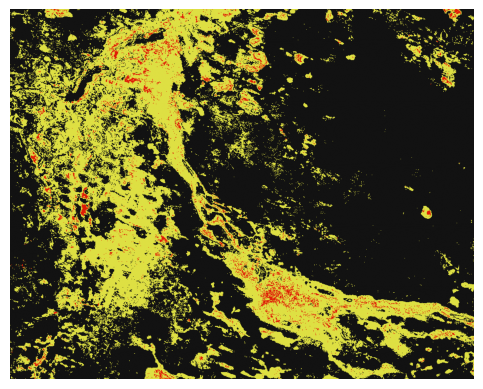

In [325]:
fig, ax = plt.subplots()
ax.imshow(gen_status, cmap=dist_cmap, norm=dist_norm)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'gen_status_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

In [326]:
dist_s1_all = (np.isin(dist_s1, [3, 6])).astype(np.uint8)
dist_veg_all = (np.isin(veg_status, [3, 6])).astype(np.uint8)
dist_gen_all = (np.isin(gen_status, [3, 6])).astype(np.uint8)

diff_veg_fp = (dist_s1_all == 1) & (dist_veg_all == 0)
diff_veg_fn = (dist_s1_all == 0) & (dist_veg_all == 1)

diff_gen_fp = (dist_s1_all == 1) & (dist_gen_all == 0)
diff_gen_fn = (dist_s1_all == 0) & (dist_gen_all == 1)

all_diff_veg = np.zeros_like(dist_s1)
all_diff_veg[diff_veg_fp] = 1
all_diff_veg[diff_veg_fn] = 2

all_diff_gen = np.zeros_like(dist_s1)
all_diff_gen[diff_gen_fp] = 1
all_diff_gen[diff_gen_fn] = 2


In [327]:
rnd_cmap, rnd_norm = create_random_colormap_matplotlib(background_val=0)


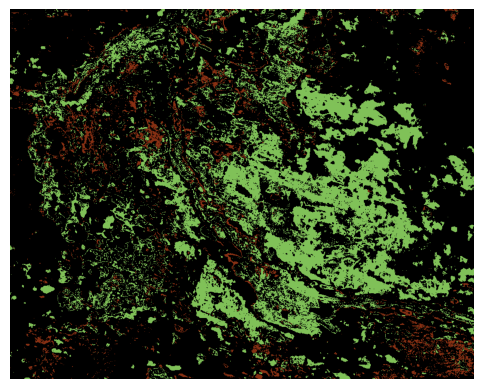

In [333]:
fig, ax = plt.subplots()
ax.imshow(all_diff_veg, cmap=rnd_cmap, norm=rnd_norm)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'differences_{KEY}_veg.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

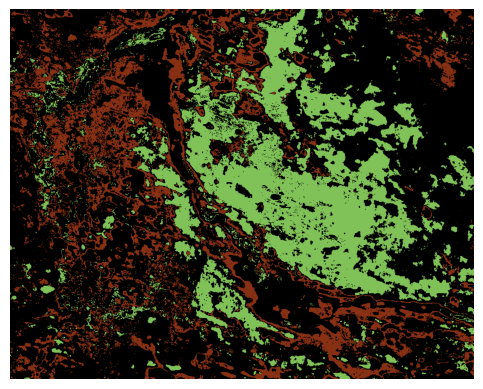

In [329]:
fig, ax = plt.subplots()
ax.imshow(all_diff_gen, cmap=rnd_cmap, norm=rnd_norm)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'differences_{KEY}_gen.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

In [330]:
X_esri, p_esri = get_basemap_for_rasterio(*bounds, zoom=15)
X_esri_r, _ = reproject_arr_to_match_profile(X_esri, p_esri, p_s1, resampling='bilinear')
X_esri_r = X_esri_r.transpose(1, 2, 0)[...,:3] / 255.

KeyboardInterrupt: 

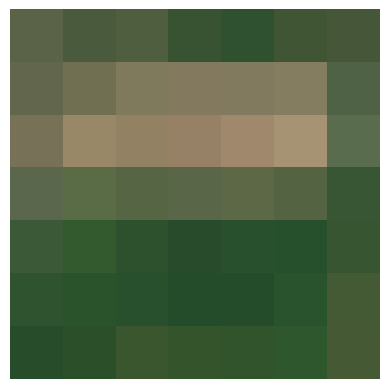

In [ ]:
fig, ax = plt.subplots()
ax.imshow(X_esri_r)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'esri_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

In [ ]:
X_google, p_google = get_basemap_for_rasterio(*bounds, zoom=15, source='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}')
X_google_r, _ = reproject_arr_to_match_profile(X_google, p_google, p_s1, resampling='bilinear')
X_google_r = X_google_r.transpose(1, 2, 0)[...,:3] / 255.

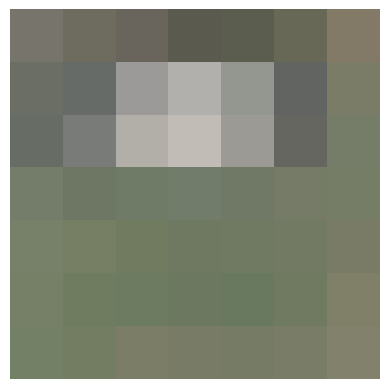

In [ ]:
fig, ax = plt.subplots()
ax.imshow(X_google_r)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'google_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

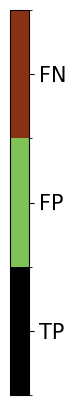

In [ ]:
fig, ax = plt.subplots(figsize=(.25, 5))

add_random_colors_colorbar(ax, color_val_map={0: 'TP', 1: 'FP', 2: 'FN'}, cmap=rnd_cmap, fontsize=15)

plt.savefig(CASE_PNG_DIR / f'diff_colorbar.png', dpi=1_000, bbox_inches='tight', pad_inches=0.1)

In [335]:
from acc import  get_confusion_matrix

tp, fp, fn, tn = get_confusion_matrix(dist_s1_all, dist_veg_all)
tp, fp, fn, tn


(np.int64(116644), np.int64(25844), np.int64(146496), np.int64(408526))

146496


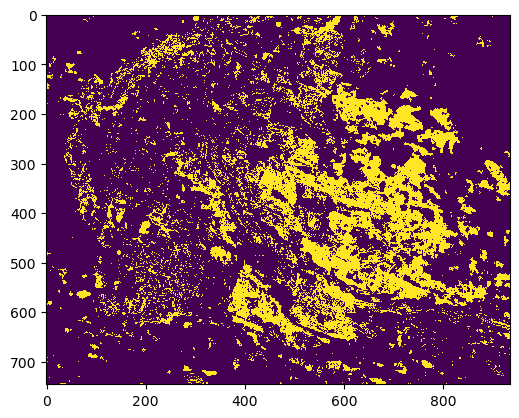

In [350]:
print(np.sum((dist_s1_all == 1)  & (dist_veg_all == 0)))
plt.imshow((dist_s1_all == 1)  & (dist_veg_all == 0), interpolation='none')

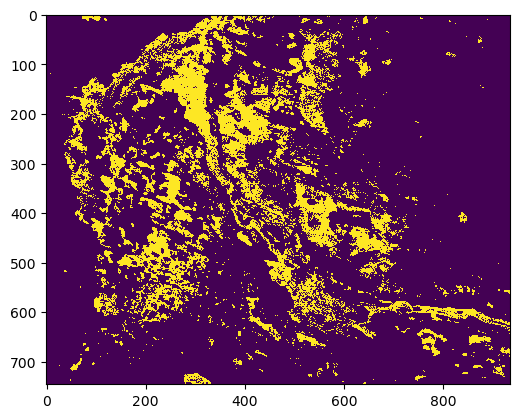

In [347]:
plt.imshow((dist_s1_all == 1)  & (dist_veg_all == 1), interpolation='none')


In [ ]:
tap / (tp + fn)

np.float64(0.4432773428593144)

In [340]:
tp / (fp + tp)

np.float64(0.8186233226657683)

In [351]:
tp,fp,  fp + tp, tp/(fp + tp)

(np.int64(116644),
 np.int64(25844),
 np.int64(142488),
 np.float64(0.8186233226657683))

In [353]:
prod_acc_veg = get_producer_accuracy(dist_veg_all, dist_s1_all)
user_acc_veg = get_user_accuracy(dist_veg_all, dist_s1_all)

print(f"Producer accuracy (veg GT): {prod_acc_veg:.2f}")
print(f"User accuracy (veg GT): {user_acc_veg:.2f}")

Producer accuracy (veg GT): 0.82
User accuracy (veg GT): 0.44


In [352]:
prod_acc_gen = get_producer_accuracy(dist_gen_all, dist_s1_all)
user_acc_gen = get_user_accuracy(dist_gen_all, dist_s1_all)

print(f"Producer accuracy (Gen GT): {prod_acc_gen:.2f}")
print(f"User accuracy (Gen GT): {user_acc_gen:.2f}")


Producer accuracy (Gen GT): 0.52
User accuracy (Gen GT): 0.43


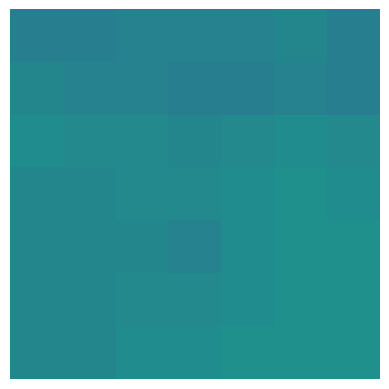

In [313]:
max_count_hls = int(np.max(dist_hls_count))
max_count_s1 = int(np.max(dist_s1_count))
max_count_all = int(max(max_count_s1, max_count_hls))


fig, ax = plt.subplots()
plt.imshow(dist_hls_count, vmin=0, vmax=max_count_all, cmap='viridis')
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'dist_hls_count_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

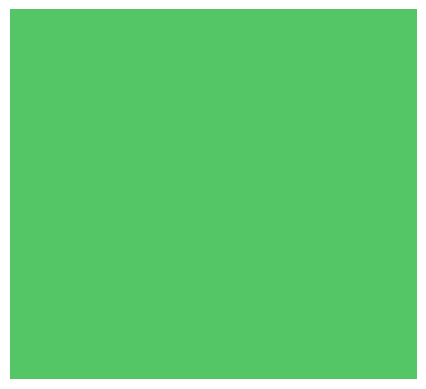

In [182]:
fig, ax = plt.subplots()
plt.imshow(dist_s1_count, vmin=0, vmax=max_count_all, cmap='viridis')
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'dist_s1_count_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=0)

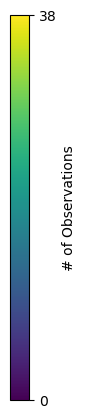

In [183]:
fig, ax = plt.subplots(figsize=(.25, 5))
add_continuous_colorbar_to_axes(ax, vmin=int(0), vmax=int(max_count_all), cmap='viridis', label='# of Observations')
plt.savefig(CASE_PNG_DIR / f'count_colorbar_{KEY}.png', dpi=1_000, bbox_inches='tight', pad_inches=1)


In [184]:
ts_dir_hls = list(Path('dist_hls/validation_sites').glob(f'*{mgrs_tile_id}/'))[0]
ts_dir_hls


PosixPath('dist_hls/validation_sites/treelosswet__49RGN')

In [185]:
last_status_file = sorted(list(ts_dir_hls.rglob('*VEG-DIST-STATUS.tif')))[-1]
last_status_file

last_status_arr, p = read_raster_from_window(last_status_file, bounds)
last_status_arr = last_status_arr[0, ...]



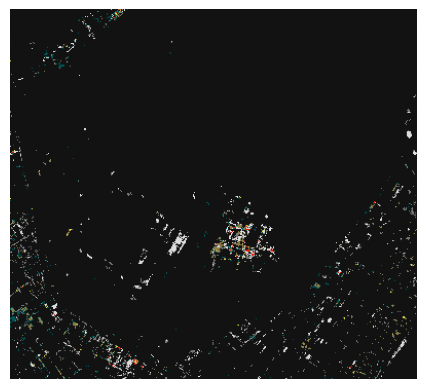

In [186]:
fig, ax = plt.subplots()
ax.imshow(last_status_arr, cmap=dist_cmap, norm=dist_norm)
ax.axis('off')
plt.savefig(CASE_PNG_DIR / f'last_{KEY}_veg_status.png', dpi=1_000, bbox_inches='tight', pad_inches=0)